In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean


In [ ]:
elevation_fine = GEBCO(coarsen_factor=1).ds
elevation = elevation_fine.coarsen(latitude=40,longitude=40).mean().elevation

In [ ]:
extent = [138,152,-68.6,-63]
east_antarctica = [70,180,-72,-60]


In [ ]:
# crop elevation
elevation_mertz = elevation_fine.sel(latitude = slice(-70,-60), longitude = slice(132,156)).elevation

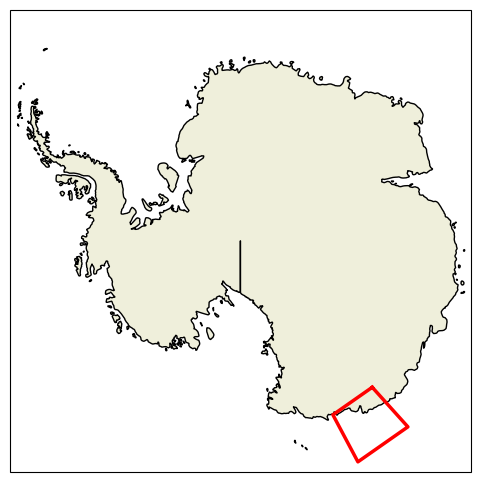

In [ ]:
#mini plot
import cartopy.feature

fig, ax = plt.subplots(figsize=(14,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
#pfns.sp(ax,xr.zeros_like(elevation),extent=[-180,180,-90,-60],cmap='RdBu')
ax.set_extent([-180,180,-90,-65], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND,edgecolor='k')

x1 = extent[0]
x2 = extent[1]
y1 = extent[2]
y2 = extent[3]
ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1],
        color='r', linewidth=2.5,
        transform=ccrs.Geodetic(), #remove this line to get straight lines
        )



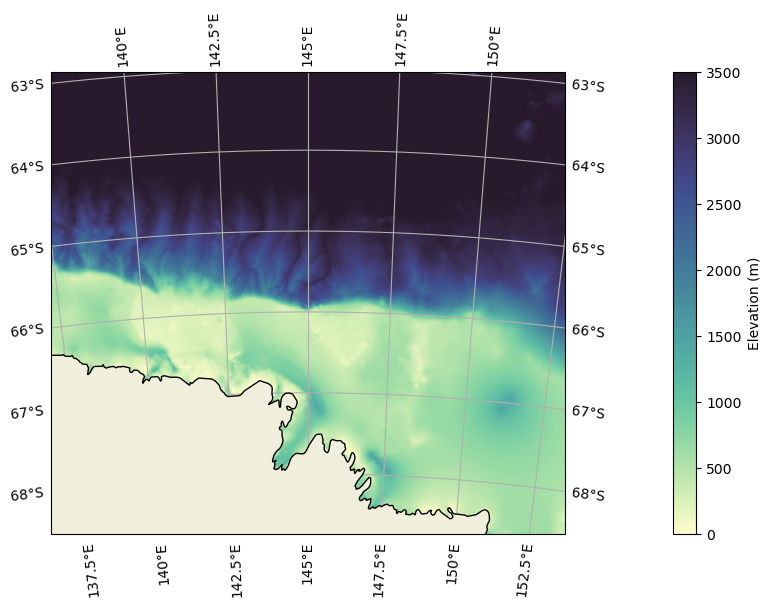

In [ ]:

fig, ax = plt.subplots(figsize=(14,6),subplot_kw={'projection':ccrs.TransverseMercator(central_longitude=145)})
pfns.sp(ax,-elevation_mertz,cbar='Elevation (m)',vmax=3500,vmin=0,extent=extent,cbar_orientation='vertical',land_zorder=2,cmap=cmocean.cm.deep)

plt.savefig("/home/users/eejco/plots/background.png", transparent=True)
